1. Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias, etc.

2. Preprocesar los datos limpiándolos, tratando valores faltantes y
transformándolos según sea necesario.

3. Seleccionar las características más relevantes para entrenar el
modelo utilizando selección de características.

4. Dividir el dataset en Train y Test para evaluar correctamente el
modelo.

5. Entrenar el modelo configurando los diferentes hiperparámetros.

6. Evaluar el desempeño del modelo en el conjunto de Test con
métricas como precisión, recall, F1-score, etc.

7. Realizar las diferentes gráficas que permitan visualizar los
resultados del modelo.

8. Interpretar, analizar y documentar los resultados obtenidos.

In [1]:
# PASO 1 ANALISIS EXPLORATORIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import  mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler


# estilo de graficos
# %matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

data = pd.read_csv("archive(1)/car details v4.csv")

# Información básica del dataset
print("\nInformación del dataset:")
data.head()


Información del dataset:


,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [2]:
# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
data.describe(include='all')


Estadísticas descriptivas:


,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2059,2059,2.059000e+03,2059.000000,2.059000e+03,2059,2059,2059,2059,2059,2059,1979,1979,1979,1923,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
unique,33,1050,NaN,NaN,NaN,9,2,77,17,6,3,108,335,290,3,NaN,NaN,NaN,NaN,NaN
top,Maruti Suzuki,X1 sDrive20d xLine,NaN,NaN,NaN,Diesel,Manual,Mumbai,White,First,Individual,1197 cc,89 bhp @ 4000 rpm,200 Nm @ 1750 rpm,FWD,NaN,NaN,NaN,NaN,NaN
freq,440,15,NaN,NaN,NaN,1049,1133,342,802,1619,1997,231,90,90,1330,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.702992e+06,2016.425449,5.422471e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,NaN,NaN,2.419881e+06,3.363564,5.736172e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,442.458507,135.265825,136.073956,0.822170,15.110198
min,NaN,NaN,4.900000e+04,1988.000000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,NaN,NaN,4.849990e+05,2014.000000,2.900000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,NaN,NaN,8.250000e+05,2017.000000,5.000000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,NaN,NaN,1.925000e+06,2019.000000,7.200000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4629.000000,1831.500000,1675.000000,5.000000,60.000000


In [3]:
# Verificar valores nulos
print("\nValores nulos por columna:")
data.isnull().sum()


Valores nulos por columna:


Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

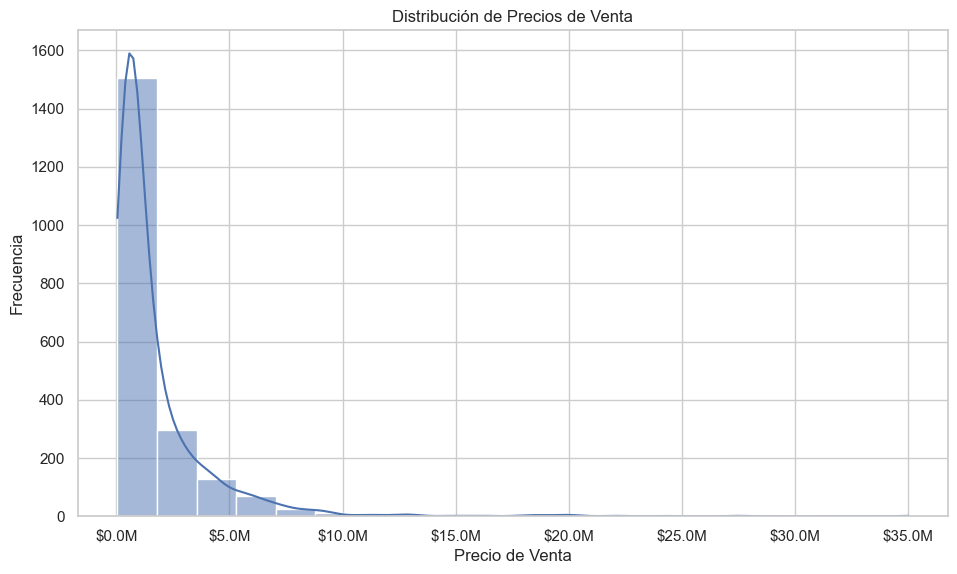

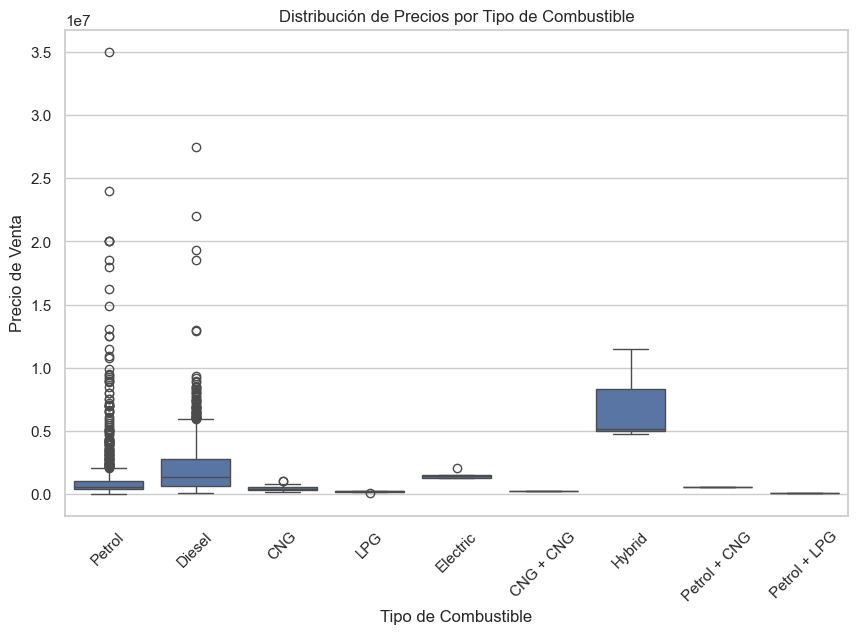

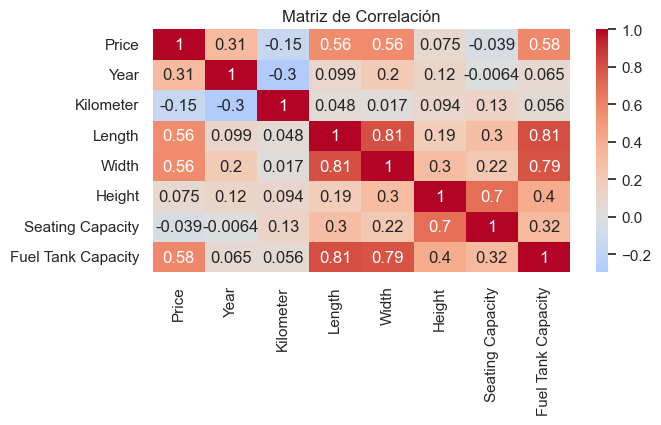

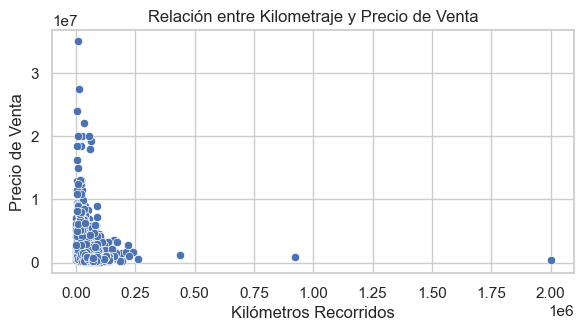

In [4]:
# Configuracion del estilo de las gráficas
sns.set(style="whitegrid")
# Configuración inicial
plt.figure(figsize=(10, 6))

# Histograma del precio


# Histograma del precio
ax = sns.histplot(x='Price', data=data, bins=20, kde=True)
# Formatear eje X en millones (para valores grandes)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1_000_000:,.1f}M'))
plt.title('Distribución de Precios de Venta')
plt.xlabel('Precio de Venta')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot de precios por tipo de combustible
plt.figure(figsize=(9, 6))
sns.boxplot(x='Fuel Type', y='Price', data=data)
plt.title('Distribución de Precios por Tipo de Combustible')
plt.xlabel('Tipo de Combustible')
plt.ylabel('Precio de Venta')
plt.xticks(rotation=45)
plt.show()

# Matriz de correlación para variables numéricas
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(6, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

# Gráfico de dispersión: Kilometraje vs Precio
plt.figure(figsize=(6, 3))
sns.scatterplot(x='Kilometer', y='Price', data=data)
plt.title('Relación entre Kilometraje y Precio de Venta')
plt.xlabel('Kilómetros Recorridos')
plt.ylabel('Precio de Venta')
plt.show()



In [5]:
#PASO 2 PREPROCESAMIENTO DE DATOS
#Primero se necesita extraer el valor numerico de las columnas Max Power, Torque y Engine, esto para tratar con valores numericos y sea mas facil trabajr los datos

# # Función para extraer valores numéricos de las columnas Max Power y Torque
def extract_power_torque(value, extract_type='value'):
    """
    Extrae valores de las columnas Max Power y Max Torque
    Parámetros:
    - value: valor de la celda
    - extract_type: 'value' para el valor principal (87 en power, 109 en torque)
                   'rpm' para las revoluciones
    """
    if pd.isna(value) or value == '':
        return np.nan
    try:
        cleaned = ' '.join(str(value).split())
        if extract_type == 'value':
            # Extraer el primer número (valor de potencia o torque)
            match = re.search(r'^(\d+\.?\d*)', cleaned)
            if match:
                return float(match.group(1))
        elif extract_type == 'rpm':
            # Extraer las RPM (número después de @)
            match = re.search(r'@\s*(\d+\.?\d*)', cleaned)
            if match:
                return float(match.group(1))
    except:
        pass
    
    return np.nan

# Aplicar la función para crear nuevas columnas numéricas
import re  # Necesario para las expresiones regulares

# Para Max Power
data['Max_Power_bhp'] = data['Max Power'].apply(lambda x: extract_power_torque(x, 'value'))
data['Max_Power_rpm'] = data['Max Power'].apply(lambda x: extract_power_torque(x, 'rpm'))

# Para Max Torque
data['Max_Torque_Nm'] = data['Max Torque'].apply(lambda x: round(extract_power_torque(x, 'value'), 1))
data['Max_Torque_rpm'] = data['Max Torque'].apply(lambda x: extract_power_torque(x, 'rpm'))

# obtener el valor numerico de la coumna Engine
def extraer_numero_simple(valor):
    if pd.isna(valor):
        return valor
    
    # Tomar solo los caracteres numéricos y punto decimal
    parte1 = str(valor).split()[0]
    if parte1.replace('.','').isdigit():
            return float(parte1)
    else:
        return None

# Aplicar la versión simple
data['Engine_cc'] = data['Engine'].apply(lambda x: extraer_numero_simple(x))

# Verificar los resultados
print("\nTransformación para Max Power:")
print(data[['Max Power', 'Max_Power_bhp', 'Max_Power_rpm']].head(10))

print("\nTransformación para Max Torque:")
print(data[['Max Torque', 'Max_Torque_Nm', 'Max_Torque_rpm']].head(10))

# Verificar las nuevas columnas
print("\nNuevas columnas:")
print(data[['Max_Power_bhp', 'Max_Power_rpm', 'Max_Torque_Nm', 'Max_Torque_rpm', 'Engine_cc']].head(20))



Transformación para Max Power:
            Max Power  Max_Power_bhp  Max_Power_rpm
0   87 bhp @ 6000 rpm           87.0         6000.0
1   74 bhp @ 4000 rpm           74.0         4000.0
2   79 bhp @ 6000 rpm           79.0         6000.0
3   82 bhp @ 6000 rpm           82.0         6000.0
4  148 bhp @ 3400 rpm          148.0         3400.0
5   91 bhp @ 6000 rpm           91.0         6000.0
6  181 bhp @ 5500 rpm          181.0         5500.0
7  188 bhp @ 4000 rpm          188.0         4000.0
8  177 bhp @ 5100 rpm          177.0         5100.0
9   84 bhp @ 3750 rpm           84.0         3750.0

Transformación para Max Torque:
               Max Torque  Max_Torque_Nm  Max_Torque_rpm
0       109 Nm @ 4500 rpm          109.0          4500.0
1       190 Nm @ 2000 rpm          190.0          2000.0
2  112.7619 Nm @ 4000 rpm          112.8          4000.0
3       113 Nm @ 4200 rpm          113.0          4200.0
4       343 Nm @ 1400 rpm          343.0          1400.0
5       130 Nm @ 4000

In [6]:
#PASO 2 PREPROCESAMIENTO DE DATOS

# Columnas numéricas con posibles valores faltantes
numeric_cols_with_nulls = ['Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity', 'Max_Power_bhp', 'Max_Power_rpm', 'Max_Torque_Nm', 'Max_Torque_rpm', 'Engine_cc']

# Asegurarnos que los datos son numéricas
for col in numeric_cols_with_nulls:
    if col in data.columns:
        # Convertir a numérico (los no convertibles serán NaN)
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Tratar valores faltantes en las nuevas columnas
for col in numeric_cols_with_nulls:
    if data[col].isnull().any():
        median_val = data[col].median()
        data[col] = data[col].fillna(median_val)

# Eliminar las columnas originales si ya no son necesarias
data = data.drop(columns=['Max Power', 'Max Torque', 'Engine'], errors='ignore')

# Columnas categóricas con nulos
categorical_cols_with_nulls = ['Drivetrain', 'Fuel Type', 'Transmission', 'Color', 'Owner', 'Seller Type']
for col in categorical_cols_with_nulls:
    if col in data.columns and data[col].isnull().any():
        mode_val = data[col].mode()[0]
        data[col] = data[col].fillna(mode_val)

print(data)
data.isnull().sum()


               Make                                  Model    Price  Year  \
0             Honda                    Amaze 1.2 VX i-VTEC   505000  2017   
1     Maruti Suzuki                        Swift DZire VDI   450000  2014   
2           Hyundai                   i10 Magna 1.2 Kappa2   220000  2011   
3            Toyota                               Glanza G   799000  2019   
4            Toyota        Innova 2.4 VX 7 STR [2016-2020]  1950000  2018   
...             ...                                    ...      ...   ...   
2054       Mahindra                  XUV500 W8 [2015-2017]   850000  2016   
2055        Hyundai                           Eon D-Lite +   275000  2014   
2056           Ford            Figo Duratec Petrol ZXI 1.2   240000  2013   
2057            BMW  5-Series 520d Luxury Line [2017-2019]  4290000  2018   
2058       Mahindra      Bolero Power Plus ZLX [2016-2019]   670000  2017   

      Kilometer Fuel Type Transmission    Location   Color   Owner  ...  \


Make                  0
Model                 0
Price                 0
Year                  0
Kilometer             0
Fuel Type             0
Transmission          0
Location              0
Color                 0
Owner                 0
Seller Type           0
Drivetrain            0
Length                0
Width                 0
Height                0
Seating Capacity      0
Fuel Tank Capacity    0
Max_Power_bhp         0
Max_Power_rpm         0
Max_Torque_Nm         0
Max_Torque_rpm        0
Engine_cc             0
dtype: int64

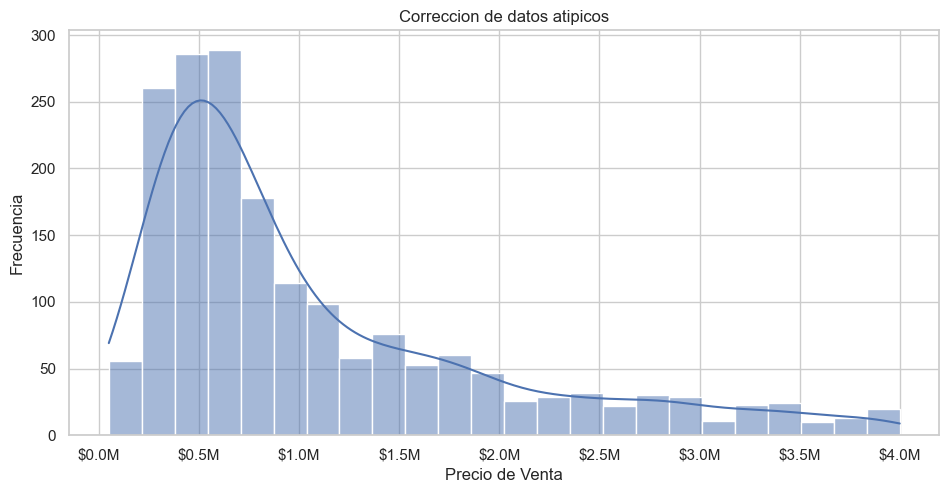

El total de datos atípicos en precio es 0


In [7]:
#Identificación de Datos Atípicos

# Calcular cuartiles
Q1 = data["Price"].quantile(0.25)
Q3 = data["Price"].quantile(0.75)
IQR = Q3 - Q1  # Rango intercuartil

# Definir límites usando 1.5 veces el IQR
nivel_minimo = Q1 - (1.5 * IQR)
nivel_maximo = Q3 + (1.5 * IQR)

tipicos=data[(data['Price']>nivel_minimo)&(data['Price']<nivel_maximo)]

plt.figure(figsize=(10, 5))
ax = sns.histplot(tipicos['Price'], kde=True)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1_000_000:,.1f}M'))
plt.title('Correccion de datos atipicos')
plt.xlabel('Precio de Venta')
plt.ylabel('Frecuencia')
plt.show()


data = tipicos

Total_Atipicos=((data['Price']<nivel_minimo)|(data['Price']>nivel_maximo)).sum()
print("El total de datos atípicos en precio es {}".format(Total_Atipicos))


Correlaciones con el precio de venta:
Price                 1.000000
Max_Power_bhp         0.746254
Max_Torque_Nm         0.741705
Width                 0.654784
Length                0.633196
Engine_cc             0.631176
Fuel Tank Capacity    0.614828
Year                  0.333846
Seating Capacity      0.178920
Height                0.168437
Kilometer            -0.084874
Name: Price, dtype: float64


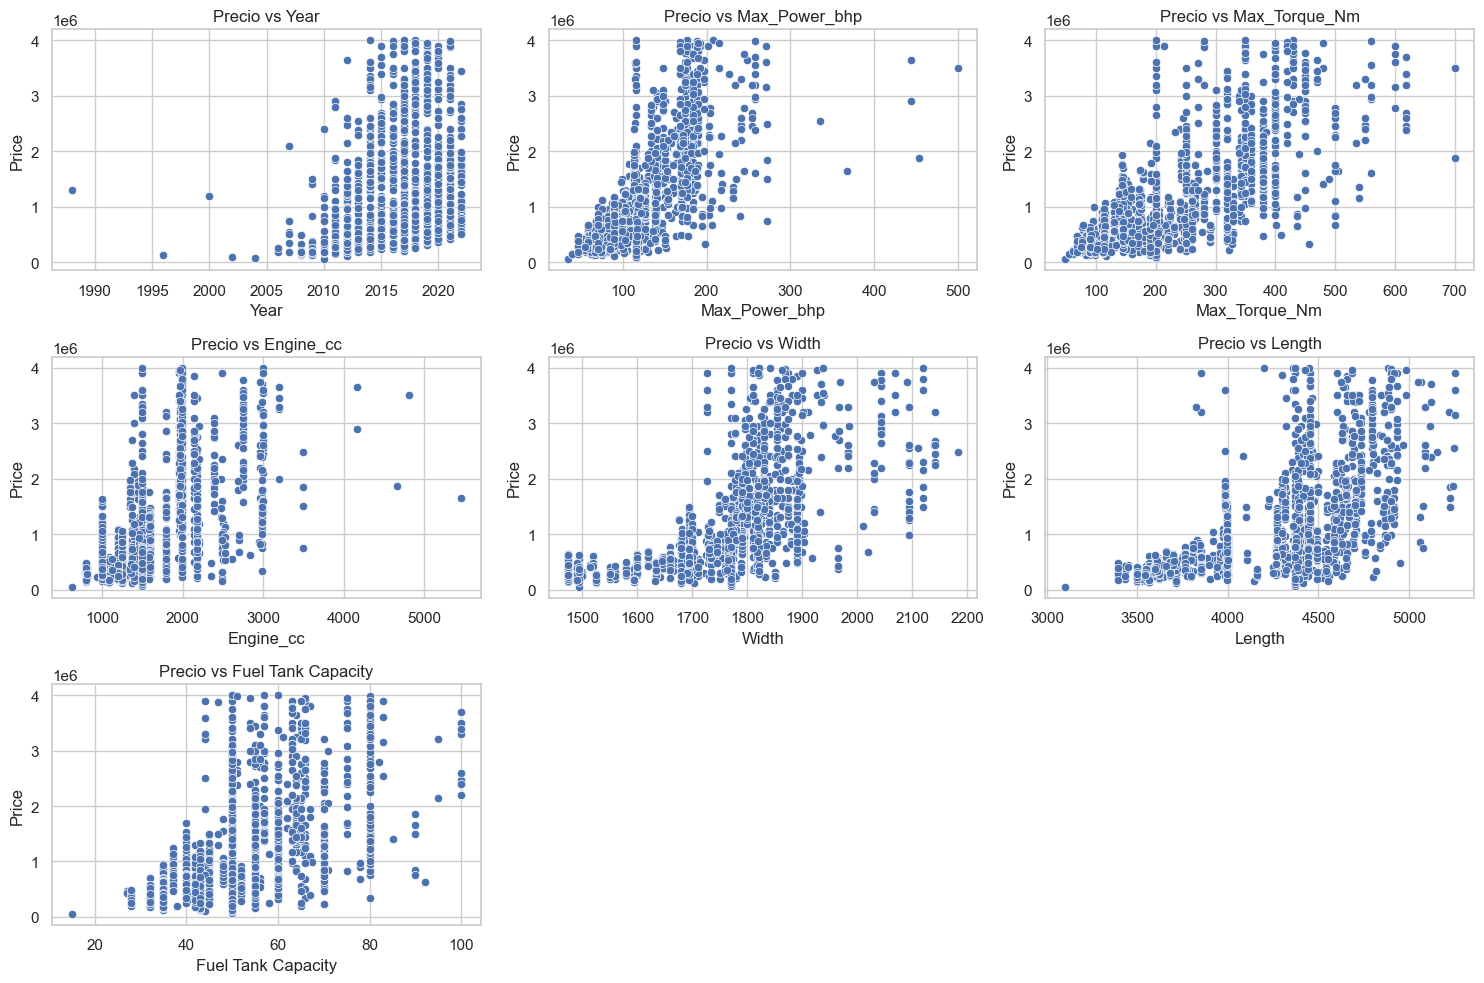

In [8]:
#PASO 3 SELECCIONAR LAS CARACTERISTICAS PRINCIPALES PARA ENTRENAR EL MODELO

columns_to_drop = ['Make', 'Model', 'Location', 'Max_Power_rpm' , 'Max_Torque_rpm', 'Fuel Type', 'Transmission', 'Color', 'Owner', 'Seller Type', 'Drivetrain']
data = data.drop(columns=[col for col in columns_to_drop if col in data.columns], errors='ignore')

# Calcular correlaciones con la variable objetivo
correlations = data.corr()['Price'].sort_values(ascending=False)
print("Correlaciones con el precio de venta:")
print(correlations)

# Seleccionar características basadas en correlación y conocimiento del dominio
selected_features = ['Year', 'Max_Power_bhp', 'Max_Torque_Nm', 'Engine_cc', 'Width', 'Length', 'Fuel Tank Capacity']


X = data[selected_features]
Y = data['Price']

# Visualizar relaciones entre características seleccionadas y el precio
plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_features):
    plt.subplot(3, 3, i+1)
    sns.scatterplot(x=col, y='Price', data=data)
    plt.title(f'Precio vs {col}')
plt.tight_layout()
plt.show()

In [9]:
#PASO 4 DIVIDIR EL DATASET EN TEST Y TRAIN
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25 , random_state=0)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

print(X_train)

print(X_test)


Tamaño del conjunto de entrenamiento: 1383 muestras
Tamaño del conjunto de prueba: 461 muestras
      Year  Max_Power_bhp  Max_Torque_Nm  Engine_cc   Width  Length  \
2036  2010          171.0          343.0     2982.0  1840.0  4695.0   
1674  2021          113.0          144.0     1497.0  1800.0  4315.0   
959   2012          116.0          146.0     1497.0  1695.0  4440.0   
1111  2021           73.0          101.0     1196.0  1475.0  3675.0   
1884  2014           84.0          200.0     1461.0  1822.0  4331.0   
...    ...            ...            ...        ...     ...     ...   
930   2014          126.0          260.0     1582.0  1700.0  4370.0   
1355  2022          138.0          242.0     1353.0  1790.0  4300.0   
1848  2019          153.0          360.0     2179.0  1890.0  4585.0   
617   2016          174.0          450.0     2755.0  1855.0  4795.0   
752   2018           89.0          113.0     1197.0  1735.0  3995.0   

      Fuel Tank Capacity  
2036                80.0

In [10]:
#PASO 5 ENTRENAMIENTO DEL MODELO

# Crear y entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, Y_train)

# Coeficientes del modelo
print("\nCoeficientes del modelo:")
for feature, coef in zip(selected_features, model.coef_):
    print(f"{feature}: {coef:.2f}")

print(f"\nIntercepto: {model.intercept_:.2f}")


Coeficientes del modelo:
Year: 90756.69
Max_Power_bhp: 8290.83
Max_Torque_Nm: 3184.41
Engine_cc: -190.82
Width: -25.53
Length: -5.53
Fuel Tank Capacity: 3366.93

Intercepto: -183341387.61


Error Cuadrático Medio (MSE): 180728635693.49
Raíz del Error Cuadrático Medio (RMSE): 425121.91
Coeficiente de Determinación (R²): 0.74

Comparación de valores reales vs predichos:
        Real      Predicho
0    3125000  2.211966e+06
1    1900000  2.277435e+06
2    1095000  1.256535e+06
3     320000  4.957198e+05
4     875000  1.109311e+06
..       ...           ...
456  1075000  1.474593e+06
457  3900000  1.737162e+06
458  2990000  2.030573e+06
459   561000  7.905998e+05
460   425000  9.468913e+05

[461 rows x 2 columns]


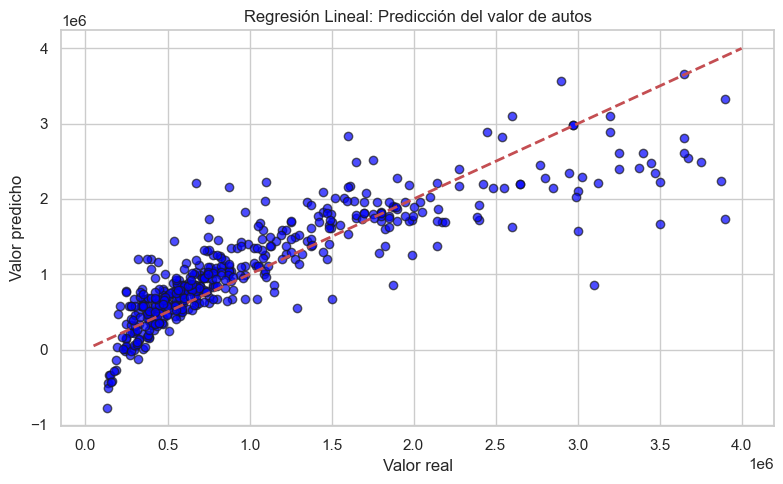

In [11]:
#PASO 6 EVALUACION DEL MODELO

# Predecir en el conjunto de prueba
Y_pred = model.predict(X_test)

# Calcular métricas de evaluación
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

# Comparar valores reales vs predichos
comparison = pd.DataFrame({'Real': Y_test, 'Predicho': Y_pred})
comparison = comparison.reset_index(drop=True)
print("\nComparación de valores reales vs predichos:")
print(comparison)

plt.figure(figsize=(8, 5))
plt.scatter(Y_test, Y_pred, color='blue', edgecolors='k', alpha=0.7)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Regresión Lineal: Predicción del valor de autos")
plt.grid(True)
plt.tight_layout()
plt.show()
